In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import os, glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import anndata
pd.set_option('display.float_format', lambda x: f'{x:.4e}' if abs(x) < 1e-3 and x != 0 else f'{x:.4f}')
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.dpi'] = 300  # or 150, 200, etc.
plt.rcParams['savefig.dpi'] = 600

# Increase all font sizes
plt.rcParams['font.size'] = 16  # Base font size
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 15

# Check perturbation effects on Measure genes of interest

In this block we want to know which perturbation in each experiment shifted the expression pattern in measured gene of interest. 
Here we are looking a CD genome wide crispr screen data for reference.

In [3]:
# Loading the CD data 
cd4_adata = sc.read_h5ad('/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/xaira_stats/CD4i_final.merged_DE_results.h5ad')
cd4_adata.obs['sample_id'] = (cd4_adata.obs[['target_contrast_gene_name', 'culture_condition']]
    .apply(lambda x: "_".join(x), axis=1))
cd4_adata.obs_names = cd4_adata.obs.sample_id
cd4_adata.var_names = cd4_adata.var.gene_name
# Split DE stats data of CD4GW as by condition
# Rest
cd4_adata_rest = cd4_adata[cd4_adata.obs.index.str.endswith('_Rest')]
cd4_adata_rest.obs_names = cd4_adata_rest.obs_names.str.split('_').str[0]
# Stim 8hr
cd4_adata_stim8 = cd4_adata[cd4_adata.obs.index.str.endswith('_Stim8hr')]
cd4_adata_stim8.obs_names = cd4_adata_stim8.obs_names.str.split('_').str[0]
# Stim 48hr
cd4_adata_stim48 = cd4_adata[cd4_adata.obs.index.str.endswith('_Stim48hr')]
cd4_adata_stim48.obs_names = cd4_adata_stim48.obs_names.str.split('_').str[0]

#### Here we extract the the DE stats layers for downstream analysis and visualization

In [43]:
# Extracting DE stats matrix
def extract_stats(adata, stats):
    df = pd.DataFrame(
        adata.layers[stats], 
        columns=adata.var_names, 
        index=adata.obs_names
    )
    # Remove the '_index' name from the columns
    df.columns.name = None
    df.index.name = None
    return df
    
# Make deseq df
def make_deseq_table(logfc_df,pval_df, basemean_df, target_gene):
    df = pd.DataFrame({
    'log_fc': logfc_df[target_gene],
    'padj': pval_df[target_gene],
    'log10baseMean+1': basemean_df[target_gene]
    })
    return df

In [5]:
# Create a dictionary mapping the string names to the actual AnnData variables
adata_dict = {
    'rest': cd4_adata_rest,
    'stim8': cd4_adata_stim8,
    'stim48': cd4_adata_stim48
}

In [14]:
samples = ['rest', 'stim8', 'stim48']
logfc_dfs = {}
pval_dfs = {}
basemean_dfs = {}

for i in samples:
    # Fetch the AnnData object using the key
    current_adata = adata_dict[i]
    
    # Pass the object (not a string) into your function
    logfc_dfs[f'cd4_{i}'] = extract_stats(current_adata, 'log_fc')
    pval_dfs[f'cd4_{i}'] = extract_stats(current_adata, 'adj_p_value')
    basemean_dfs[f'cd4_{i}'] = extract_stats(current_adata, 'baseMean')
    basemean_dfs[f'cd4_{i}'] =  np.log10(basemean_dfs[f'cd4_{i}']+1)

### Quick sanity check for on-target effects genes
Here we want to see a global picture of the on-target effects of the perturbations, how the DE stats look like before we do some downstream analysis.

In [16]:
def make_ontarget_df(logfc_df, padj, base_mean):
    # Select only columns that are also present in the index
    matched_columns = logfc_df.columns.intersection(logfc_df.index)
    logfc_df_filtered = logfc_df[matched_columns]
    padj_df_filtered = padj[matched_columns]
    on_target = pd.DataFrame({
    'logFC': pd.Series({gene: logfc_df.loc[gene, gene] for gene in matched_columns if gene in logfc_df.index}),
    'padj': pd.Series({gene: padj.loc[gene, gene] for gene in matched_columns if gene in logfc_df.index}),
    'baseMean': pd.Series({gene: base_mean.loc[gene, gene] for gene in matched_columns if gene in logfc_df.index})})
    on_target = on_target.dropna(subset=['logFC', 'padj'])
    on_target['significant'] = on_target['padj'] < 0.1
    return on_target

In [17]:
on_target_effects = {}
for k in logfc_dfs.keys():
    on_target_effects[k] = make_ontarget_df(logfc_dfs[k], pval_dfs[k], basemean_dfs[k])

In [20]:
def plot_logfc_vs_basemean(on_target, k):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(on_target.loc[~on_target['significant'], 'baseMean'],
        on_target.loc[~on_target['significant'], 'logFC'],
        s=10, alpha=0.4, color='grey', label='NS'
    )
    ax.scatter(
        on_target.loc[on_target['significant'], 'baseMean'],
        on_target.loc[on_target['significant'], 'logFC'],
        s=15, alpha=0.6, color='red', label='padj < 0.1'
    )

    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel('log10(baseMean + 1)')
    ax.set_ylabel('logFC')
    ax.set_title(f'On-Target Effects: logFC vs baseMean - {k}')
    ax.legend()
    plt.tight_layout()
    plt.show()

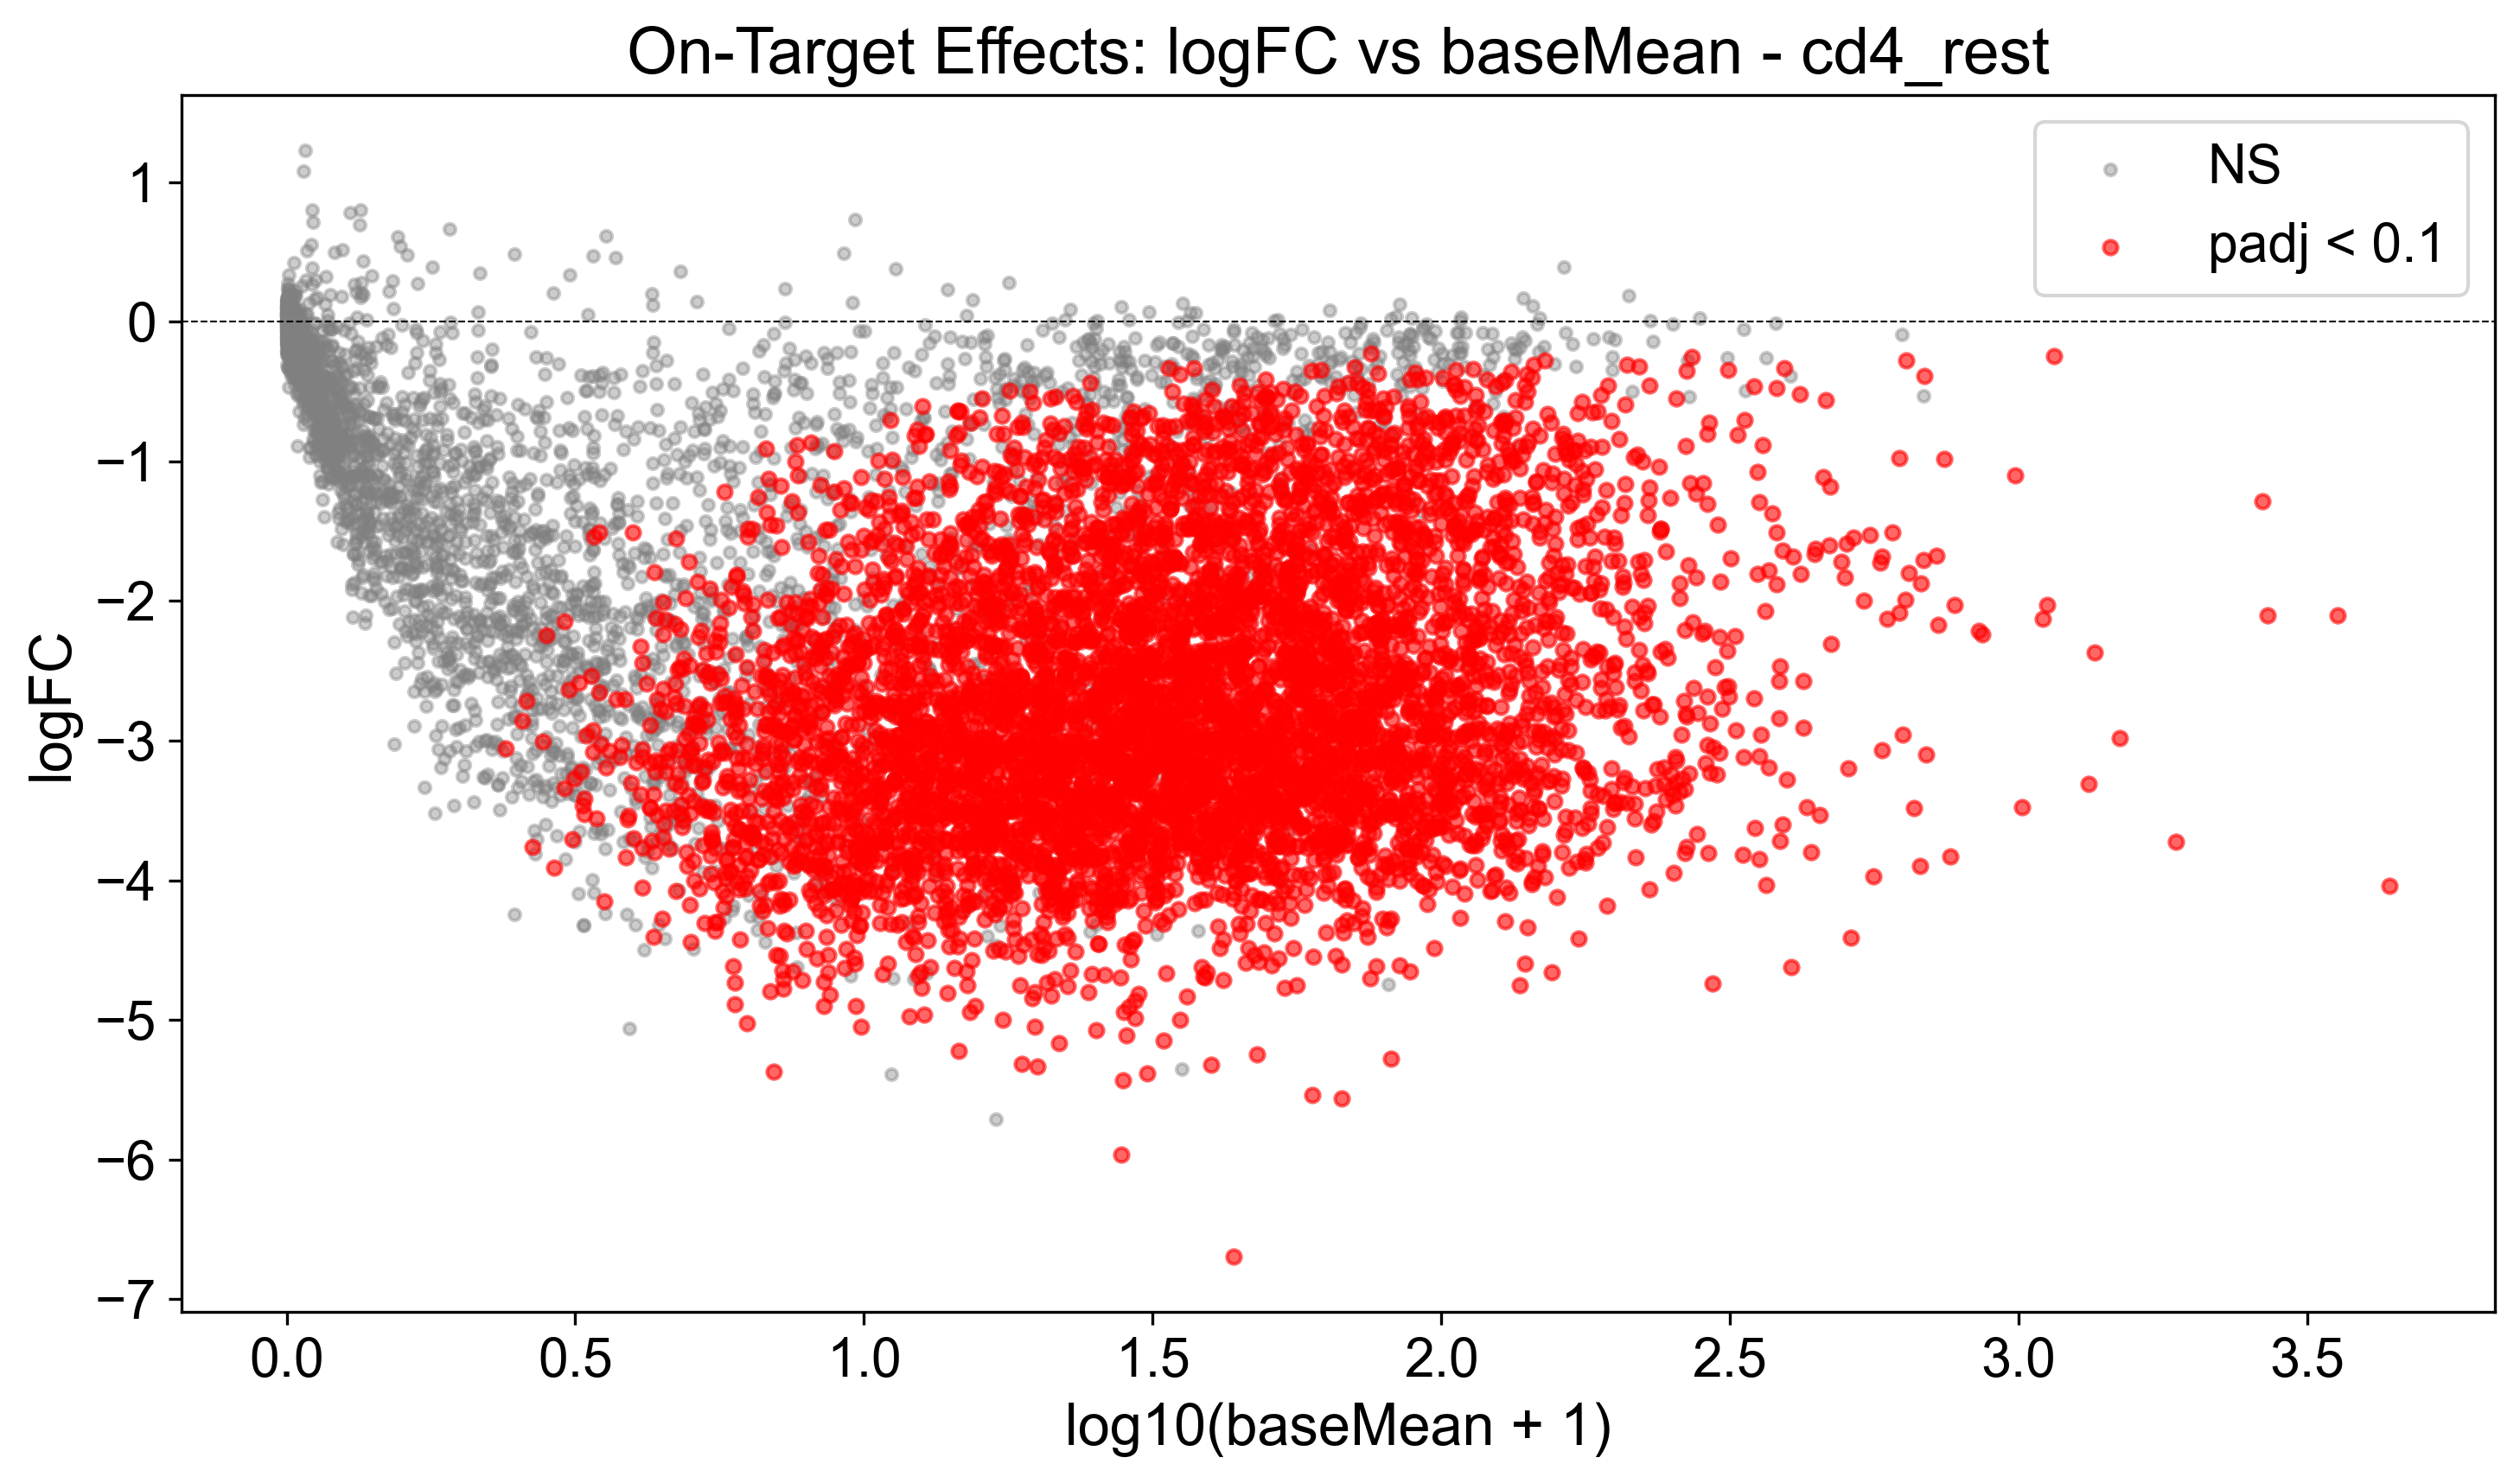

In [21]:
plot_logfc_vs_basemean(on_target_effects['cd4_rest'],'cd4_rest' )

In [26]:
def plot_ranked_perturbation(on_target):
    on_target = on_target.sort_values('logFC')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: bar plot without labels
    ax = axes[0]
    colors = on_target['significant'].map({True: 'steelblue', False: 'lightgrey'})
    ax.bar(range(len(on_target)), on_target['logFC'], color=colors, width=1.0, linewidth=0)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('log FC (on-target)')
    ax.set_title(f'On-Target Effects: {on_target["significant"].sum()}/{len(on_target)} significant (padj < 0.1)')
    ax.set_xlabel('Genes (ranked by logFC)')
    ax.set_xticks([])
    
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='steelblue', label='Significant'),
                       Patch(color='lightgrey', label='Not significant')])
    
    # Right: histogram of on-target logFC
    ax2 = axes[1]
    ax2.hist(on_target['logFC'].dropna(), bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
    ax2.axvline(0, color='black', linewidth=0.8)
    ax2.axvline(on_target['logFC'].median(), color='red', linestyle='--', label=f'Median: {on_target["logFC"].median():.3f}')
    ax2.set_xlabel('log FC (on-target)')
    ax2.set_ylabel('Count')
    ax2.set_title('Distribution of On-Target logFC')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

Remaining after dropping NaN:             logFC       padj  baseMean  significant
TSPAN6    -0.0370     1.0000    0.0026        False
DPM1      -1.7035 1.9758e-65    1.9588         True
SCYL3     -1.0481     0.0014    1.3816         True
C1orf112  -2.2944 8.6887e-39    1.7356         True
FGR        0.2568     1.0000    0.0260        False
...           ...        ...       ...          ...
CCDC39     0.1008     1.0000    0.0010        False
ARHGAP11B -2.4852 3.7092e-25    1.5875         True
F8A1      -1.2466     1.0000    0.2514        False
HOMEZ     -3.5018 1.0087e-18    1.1904         True
SOD2      -2.3276 1.1614e-27    1.6748         True

[9756 rows x 4 columns]
Median on-target logFC: -2.343
Fraction negative: 97.2%
Fraction significant & negative: 66.5%


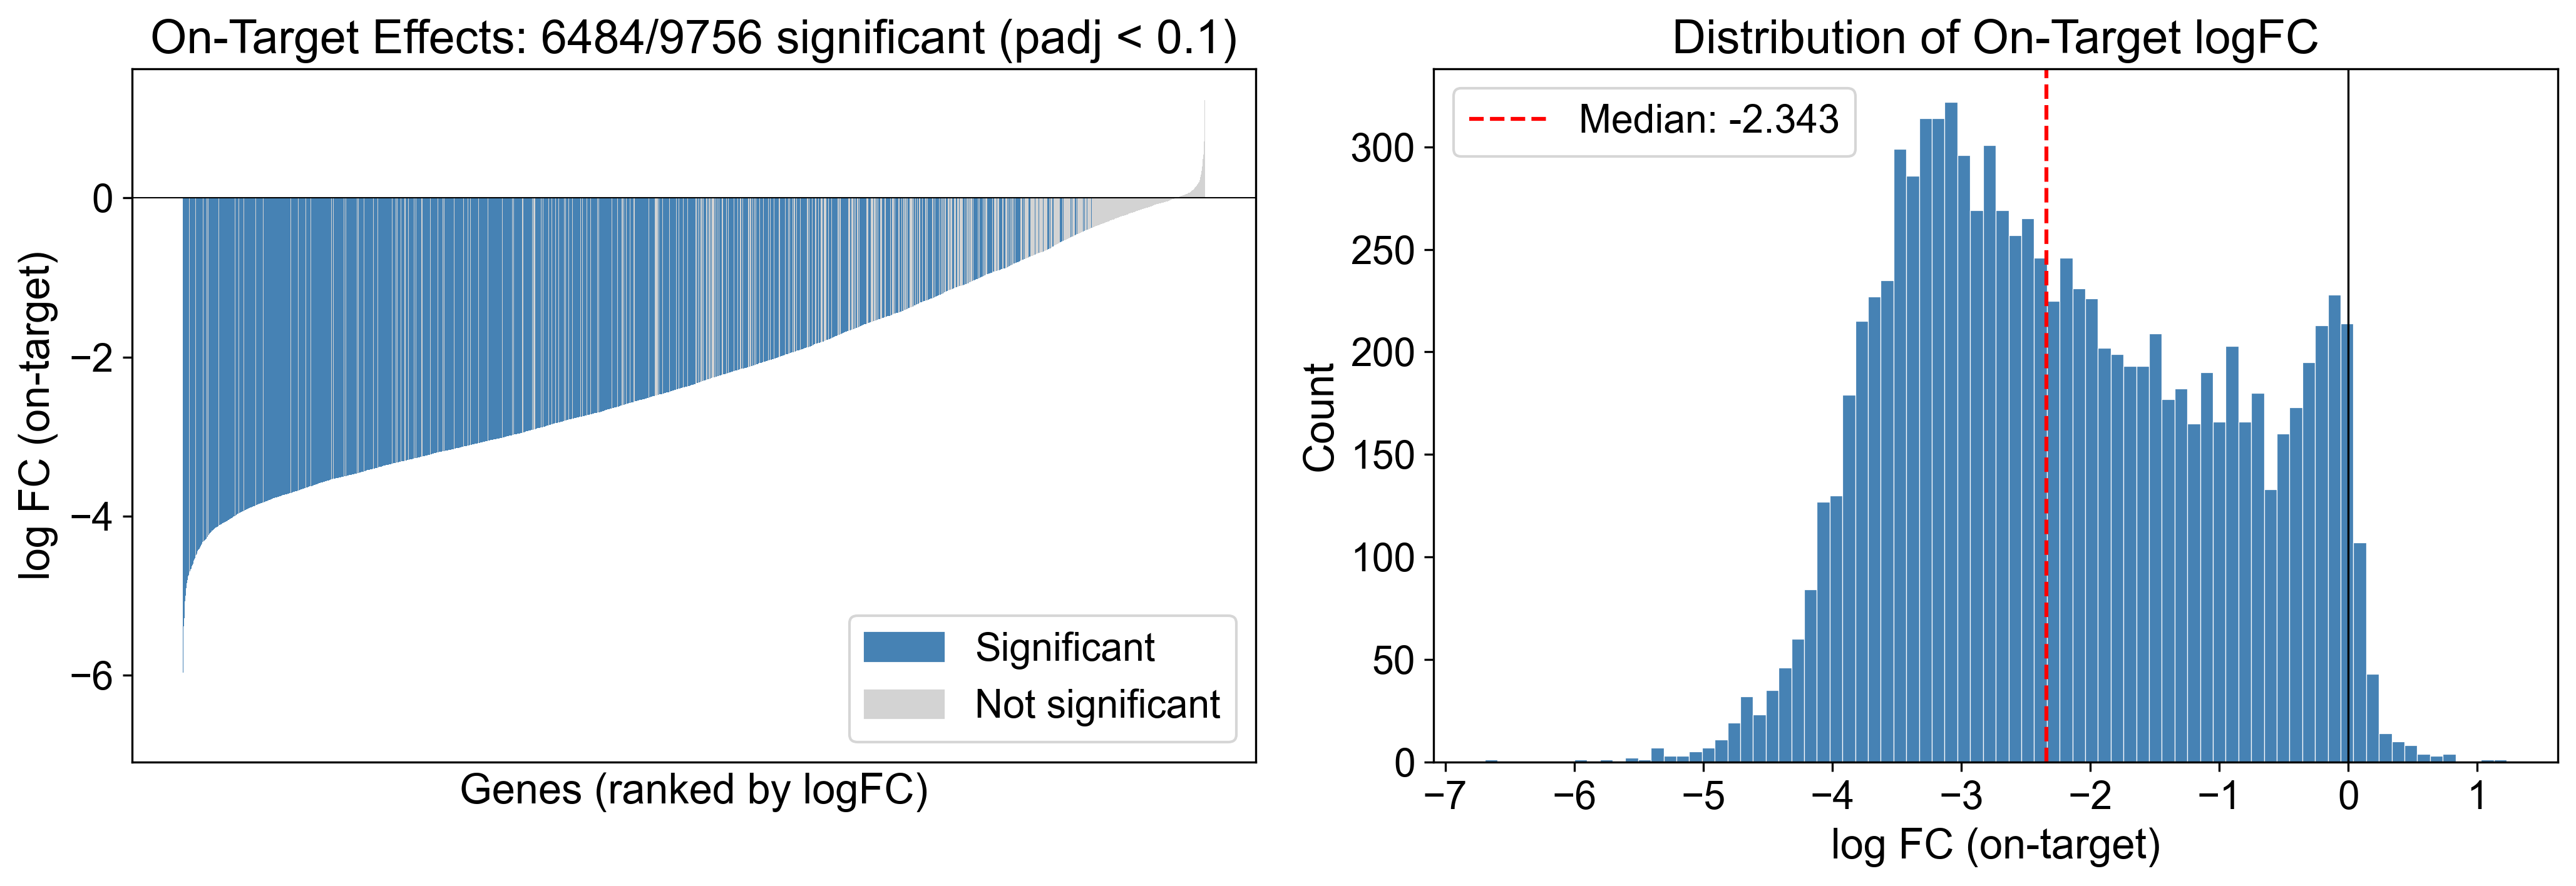

In [27]:
print(f"Remaining after dropping NaN: {on_target_effects['cd4_rest']}")
print(f"Median on-target logFC: {on_target_effects['cd4_rest']['logFC'].median():.3f}")
print(f"Fraction negative: {(on_target_effects['cd4_rest']['logFC'] < 0).mean():.1%}")
print(f"Fraction significant & negative: {((on_target_effects['cd4_rest']['padj'] < 0.1) & (on_target_effects['cd4_rest']['logFC'] < 0)).mean():.1%}")
plot_ranked_perturbation(on_target_effects['cd4_rest'])

#### Now we remove perturbation where the basemean is very low and check for the on_target effects

In [28]:
for k,v in on_target_effects.items():
    on_target_effects[k] = v[v['baseMean'] >= 0.7]

Remaining after dropping NaN:             logFC       padj  baseMean  significant
DPM1      -1.7035 1.9758e-65    1.9588         True
SCYL3     -1.0481     0.0014    1.3816         True
C1orf112  -2.2944 8.6887e-39    1.7356         True
FUCA2     -3.2211 2.7825e-09    1.1440         True
GCLC      -0.9538     0.0843    1.5425         True
...           ...        ...       ...          ...
PAGR1     -2.7222 1.9744e-60    1.7873         True
SCO2      -2.6382 1.6247e-22    1.2335         True
ARHGAP11B -2.4852 3.7092e-25    1.5875         True
HOMEZ     -3.5018 1.0087e-18    1.1904         True
SOD2      -2.3276 1.1614e-27    1.6748         True

[7345 rows x 4 columns]
Median on-target logFC: -2.685
Fraction negative: 99.5%
Fraction significant & negative: 86.8%


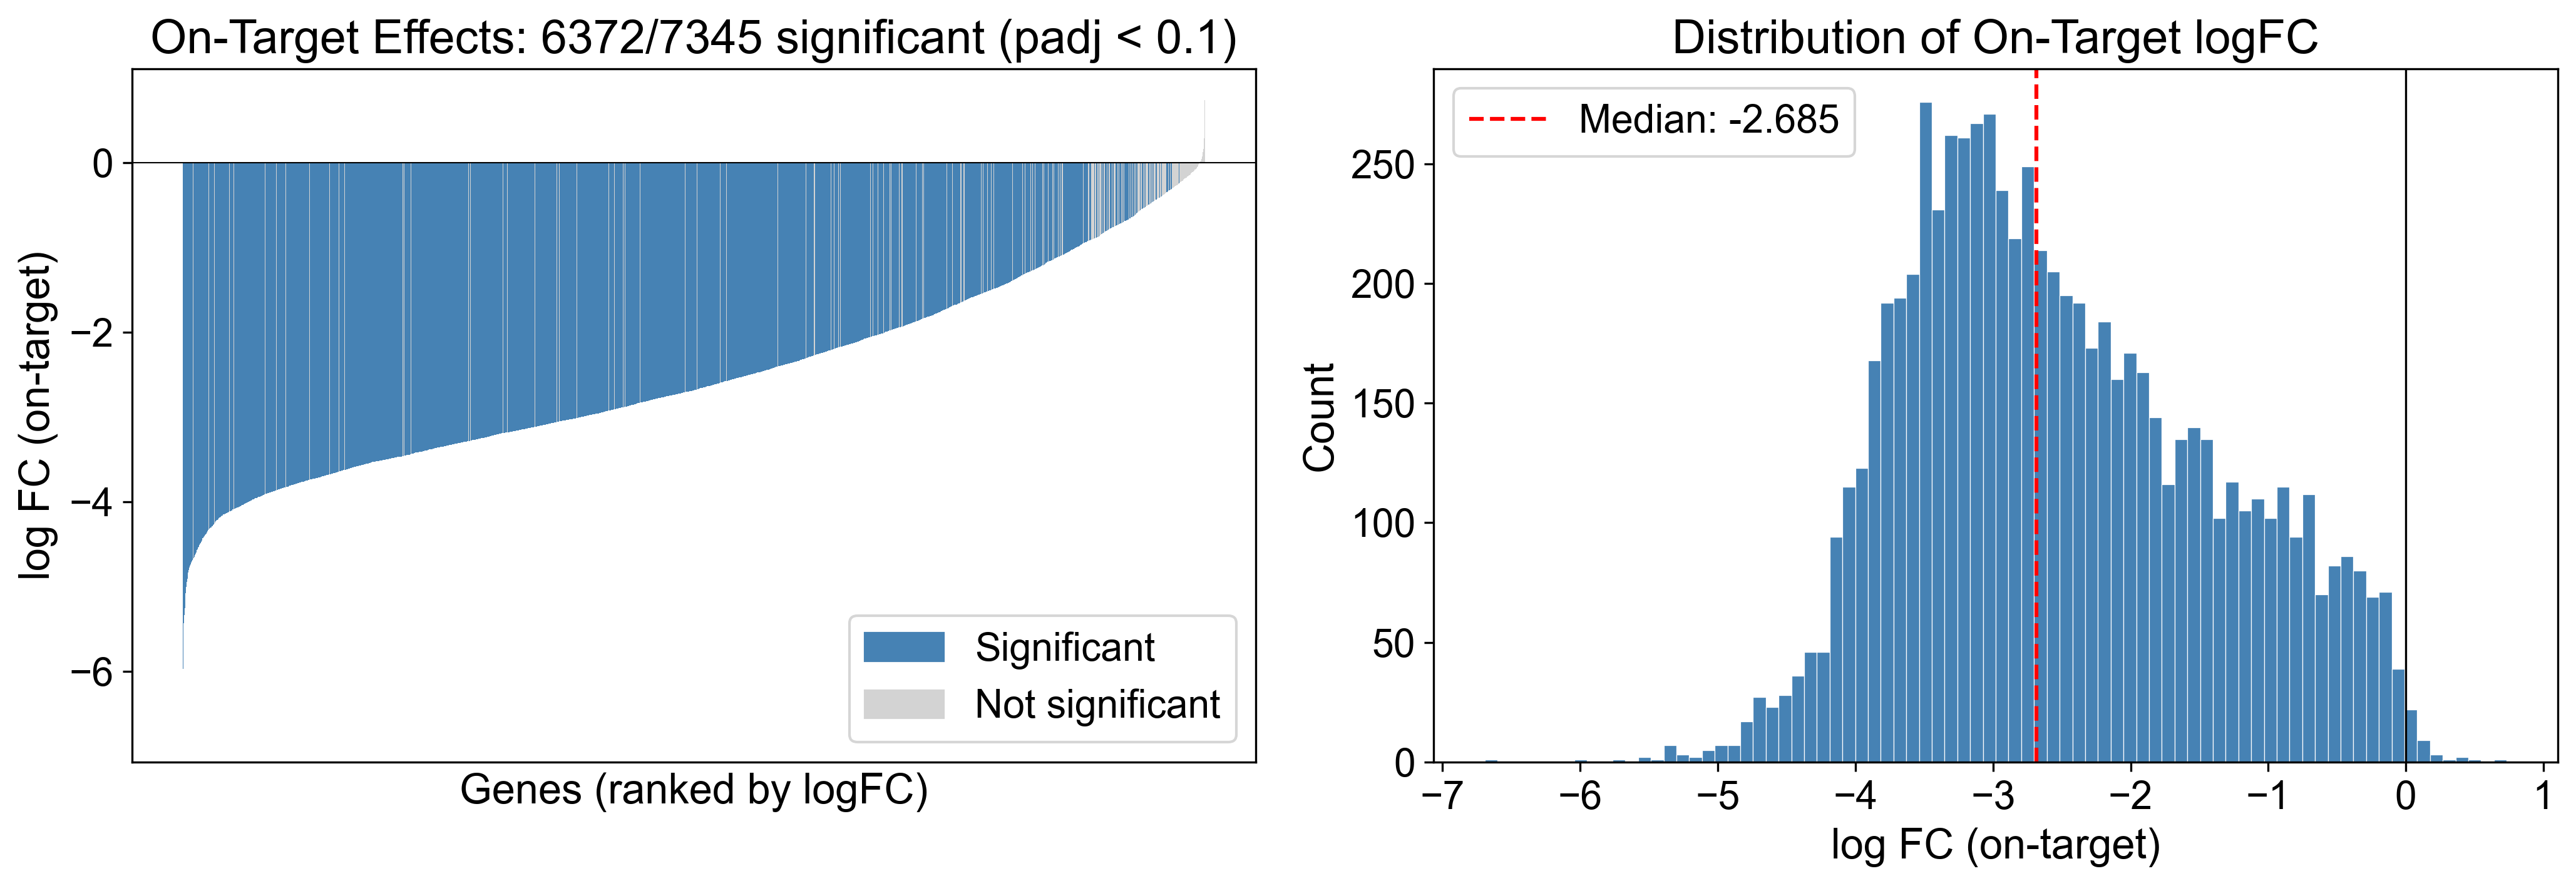

In [29]:
print(f"Remaining after dropping NaN: {on_target_effects['cd4_rest']}")
print(f"Median on-target logFC: {on_target_effects['cd4_rest']['logFC'].median():.3f}")
print(f"Fraction negative: {(on_target_effects['cd4_rest']['logFC'] < 0).mean():.1%}")
print(f"Fraction significant & negative: {((on_target_effects['cd4_rest']['padj'] < 0.1) & (on_target_effects['cd4_rest']['logFC'] < 0)).mean():.1%}")
plot_ranked_perturbation(on_target_effects['cd4_rest'])

## Next we move to check some exhaustion related genes and cytokines genes, this list needs to be modified as required

In [30]:
genes_of_interest = {
    'exhaustion markers':["HAVCR2","ENTPD1","LAG3","CD160","GZMB","TOX","ID2","CX3CR1","KLRG1","TIGIT","CD244","CXCL13"],
    'cytokines':["IL10", "IL2", "IFNG", "TNF", "PRDM1"]
}

In [50]:
cd4_stim48_cytokines = {}
for gene in genes_of_interest['cytokines']:
    cd4_stim48_cytokines[gene] = make_deseq_table(logfc_dfs['cd4_stim48'], pval_dfs['cd4_stim48'], 
                                                  basemean_dfs['cd4_stim48'], gene)

In [56]:
from adjustText import adjust_text
def plot_volcano(
    df,
    key,
    target_gene,
    log2fc_thresh=1.0,
    p_thresh=0.1,
):
    """Generates a volcano plot from a differential expression dataframe.

    Parameters:
    -----------
    df : pandas.DataFrame
        The input dataframe. Gene names should be the index, and it must
        contain
        'log_fc' and 'adj_p_value' columns.
    
    log2fc_thresh : float, optional
        Threshold for $|\log_2 \text{ FC}|$ significance. Default is 1.0.
    p_thresh : float, optional
        Threshold for adjusted p-value significance. Default is 0.1.
    top_n_labels : int or None, optional
        Number of most significant genes to label on each side (Up/Down).
        Set to None to label all significant genes. Default is 5.
    """
    # Create a copy to prevent modifying the original DataFrame or causing SettingWithCopyWarning
    plot_df = df.copy()

    # 1. Calculate -log10(adj_p_value)
    plot_df["-log10_p"] = -np.log10(plot_df["padj"] + 1e-300)

    # 2. Categorize genes for color-coding
    conditions = [
        (plot_df["log_fc"] > log2fc_thresh)
        & (plot_df["padj"] < p_thresh),
        (plot_df["log_fc"] < -log2fc_thresh)
        & (plot_df["padj"] < p_thresh),
    ]
    choices = ["Negative regulator", "Positive regulator"]
    plot_df["Significance"] = np.select(
        conditions, choices, default="Not Significant"
    )

    # 3. Create the base plot
    plt.figure(figsize=(9, 7))
    sns.scatterplot(
        data=plot_df,
        x="log_fc",
        y="-log10_p",
        hue="Significance",
        palette={
            "Negative regulator": "#ff4d4d",
            "Positive regulator": "#1e90ff",
            "Not Significant": "#b0c4de",
        },
        alpha=0.7,
        edgecolor=None,
    )

    # 4. Add threshold lines
    plt.axvline(x=log2fc_thresh, color="gray", linestyle="--", linewidth=1)
    plt.axvline(x=-log2fc_thresh, color="gray", linestyle="--", linewidth=1)
    plt.axhline(
        y=-np.log10(p_thresh), color="gray", linestyle="--", linewidth=1
    )

    # 5. Filter for significant groups
    downregulated_genes = plot_df[plot_df["Significance"] == "Positive regulator"]
    upregulated_genes = plot_df[plot_df["Significance"] == "Negative regulator"]

    # Create a list to hold text objects for both groups
    texts = []

    # Add downregulated labels
    for gene_name, row in downregulated_genes.iterrows():
        texts.append(
            plt.text(
                row["log_fc"],
                row["-log10_p"],
                gene_name,
                fontsize=10,
                fontweight="bold",
                color="black",
            )
        )

    # Add upregulated labels
    for gene_name, row in upregulated_genes.iterrows():
        texts.append(
            plt.text(
                row["log_fc"],
                row["-log10_p"],
                gene_name,
                fontsize=10,
                fontweight="bold",
                color="black",
            )
        )

    # Use adjust_text to automatically push labels away from dots and each other
    if texts:
        adjust_text(
            texts,
            arrowprops=dict(arrowstyle="->", color="black", lw=0.7, alpha=0.6),
            expand=(1.5, 1.5),  # Gives labels extra breathing room
        )

    # 6. Labels and Styling
    plt.title(f"{key} - {target_gene}", fontsize=14, pad=15)
    plt.xlabel(r"Log2 Fold Change ($\log_2$ FC)")
    plt.ylabel(r"$-\log{10}$ Adjusted P-value")
    plt.legend(
        title="Gene Status", bbox_to_anchor=(1.05, 1), loc="upper left"
    )
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

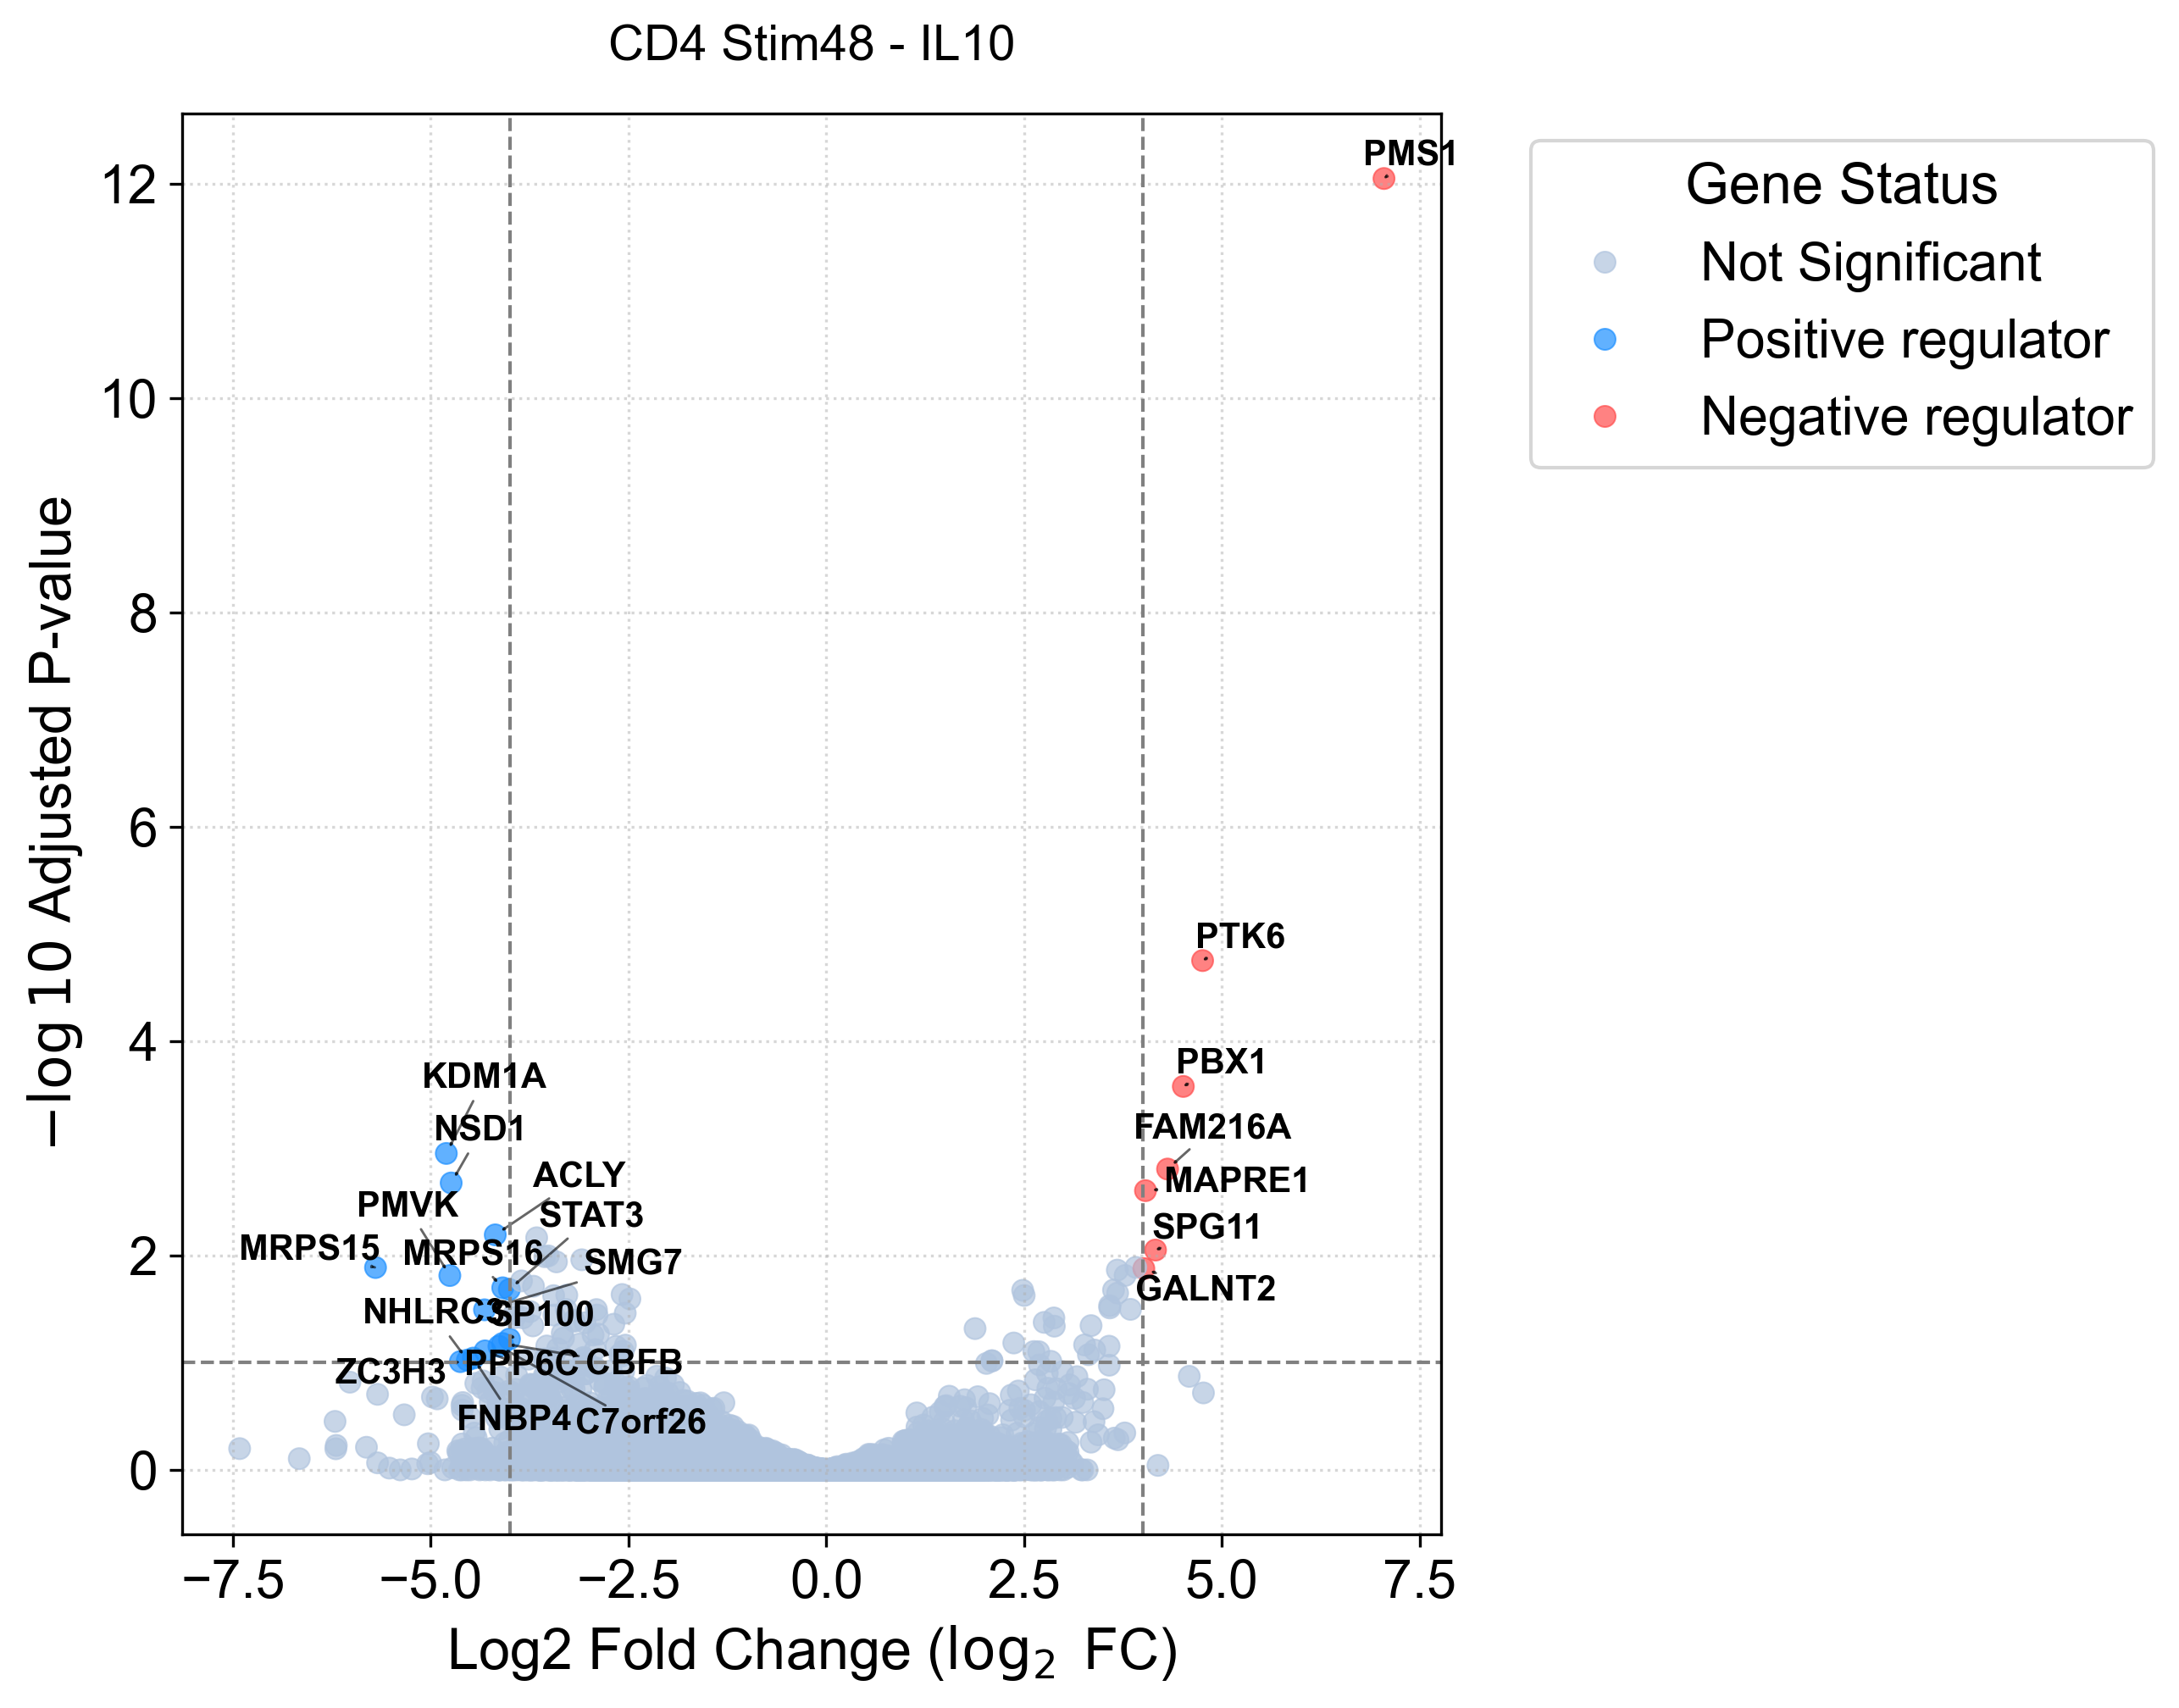

In [57]:
plot_volcano(cd4_stim48_cytokines['IL10'], 'CD4 Stim48', 'IL10', log2fc_thresh= 4)